## **Import Libraries**

In [1]:
import numpy as np 
import pandas as pd 
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahendrapalsaniya/e-commerce-order-transactions-dataset/E_Com-orders.xlsx


In [2]:
df = pd.read_excel("/kaggle/input/datasets/mahendrapalsaniya/e-commerce-order-transactions-dataset/E_Com-orders.xlsx")
df.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## **Shape & info.**

In [3]:
df.shape

(1200, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

## **Data Cleaning** 

### 1. Handling Missing and Null values

In [5]:
a = df.isnull().sum()
a

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
# Missing Percentage
print (a/len(df)*100)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [7]:
df['CouponCode'] = df['CouponCode'].fillna("NO-COUPON")

In [8]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

### 2. Check for Duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

##### -> There is no duplicate values in all features

### 3. Checking for Data formats

In [10]:
text_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print('All the Categorical column are in a single Format')

All the Categorical column are in a single Format


##### -> Here all the categorical columns are in same format except 'Coupan' (This is in uppeecase)

In [11]:
df['UnitPrice']  = df['UnitPrice'].round(2)
df['TotalPrice'] = df['TotalPrice'].round(2)

In [12]:
min_date = str(df['Date'].min().date())
max_date = str(df['Date'].max().date())

print(min_date," -> ",max_date)

2023-01-01  ->  2025-06-30


##### -> Here data is from 1 jan 2023 to 30 june 2025 

### 4. Store cleaned Dataset

In [13]:
df.to_csv("Cleaned.csv",index=False)
print("Cleaned Dataset stored in csv file")

Cleaned Dataset stored in csv file


## **Exploratory Data Analysis (EDA)**

In [14]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


### 1. Data Description

In [15]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### 2. Mean, Median & Mode

In [16]:
num_cols = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
for i in num_cols:
    print(f"mean of column {i} is : {df[i].mean()}")
    print(f"median of column {i} is : {df[i].median()}")
    print(f"mode of column {i} is : {df[i].mode()}\n")

mean of column Quantity is : 2.9458333333333333
median of column Quantity is : 3.0
mode of column Quantity is : 0    1
Name: Quantity, dtype: int64

mean of column UnitPrice is : 356.41275
median of column UnitPrice is : 364.21
mode of column UnitPrice is : 0    127.18
1    133.39
2    136.84
3    183.67
4    228.91
5    466.42
6    629.34
Name: UnitPrice, dtype: float64

mean of column ItemsInCart is : 5.485
median of column ItemsInCart is : 5.0
mode of column ItemsInCart is : 0    5
Name: ItemsInCart, dtype: int64

mean of column TotalPrice is : 1053.9683
median of column TotalPrice is : 823.615
mode of column TotalPrice is : 0     211.14
1     367.34
2     410.52
3     635.90
4    2517.36
Name: TotalPrice, dtype: float64



### 3. Skewness

In [17]:
df[num_cols].skew()

Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

### 4. Outliers detection

In [18]:
Q1 = df['TotalPrice'].quantile(0.25)
Q2 = df['TotalPrice'].quantile(0.50)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

Max = Q3 + 1.5 * IQR
Min = Q1 - 1.5 * IQR

print("TotalPrice Outlier are b/w :")
print("Minimum : ",Min)
print("Maximum : ",Max)

TotalPrice Outlier are b/w :
Minimum :  -1341.4125
Maximum :  3330.4075


In [19]:
df[df['TotalPrice'] > Max]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO-COUPON,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO-COUPON,Facebook,3390.95


#### Plot Outliers

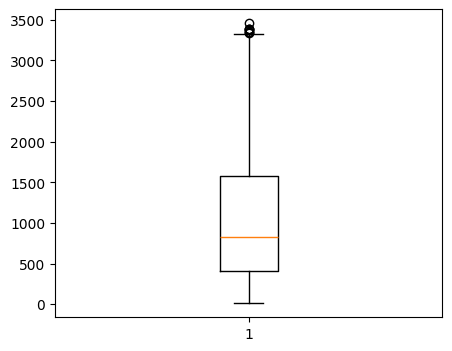

In [20]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df['TotalPrice'])
plt.show()

### 5. Distribution of totalprice

Saved plots to: eda_plots.png


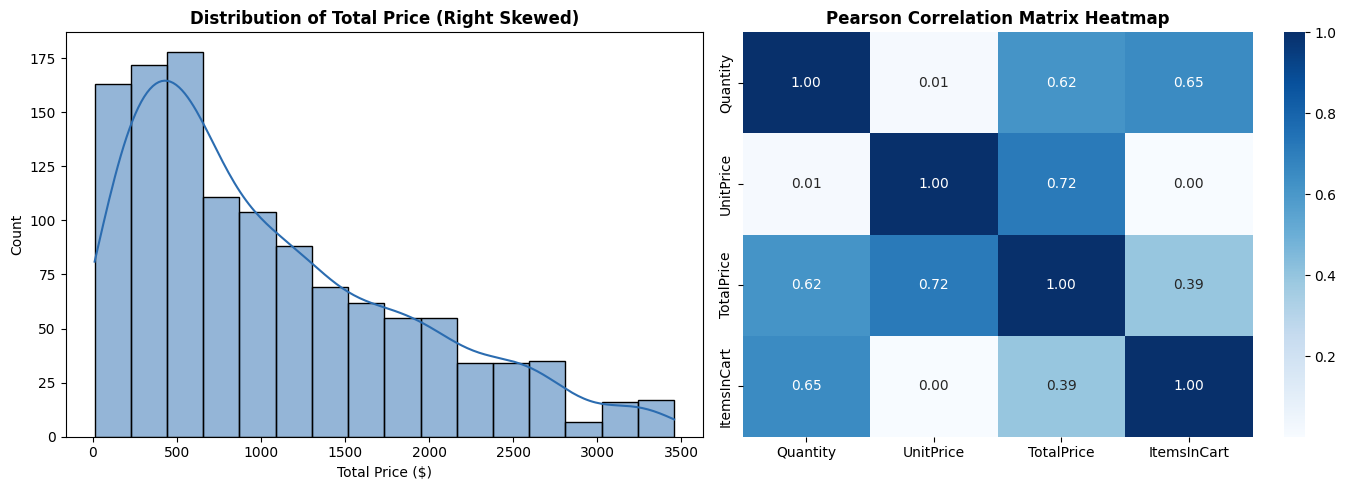

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Price Distribution
sns.histplot(df['TotalPrice'], kde=True, ax=axes[0], color='#2b6cb0')
axes[0].set_title('Distribution of Total Price (Right Skewed)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Count')

# 2. Correlation Matrix Heatmap
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr(),
            annot=True, cmap='Blues', fmt='.2f', ax=axes[1])
axes[1].set_title('Pearson Correlation Matrix Heatmap', fontsize=12, 
                  fontweight='bold')

plt.tight_layout()
eda_chart_path = 'eda_plots.png'
plt.savefig(eda_chart_path)
print("Saved plots to:", eda_chart_path)

### 6. Categorical Columns Count

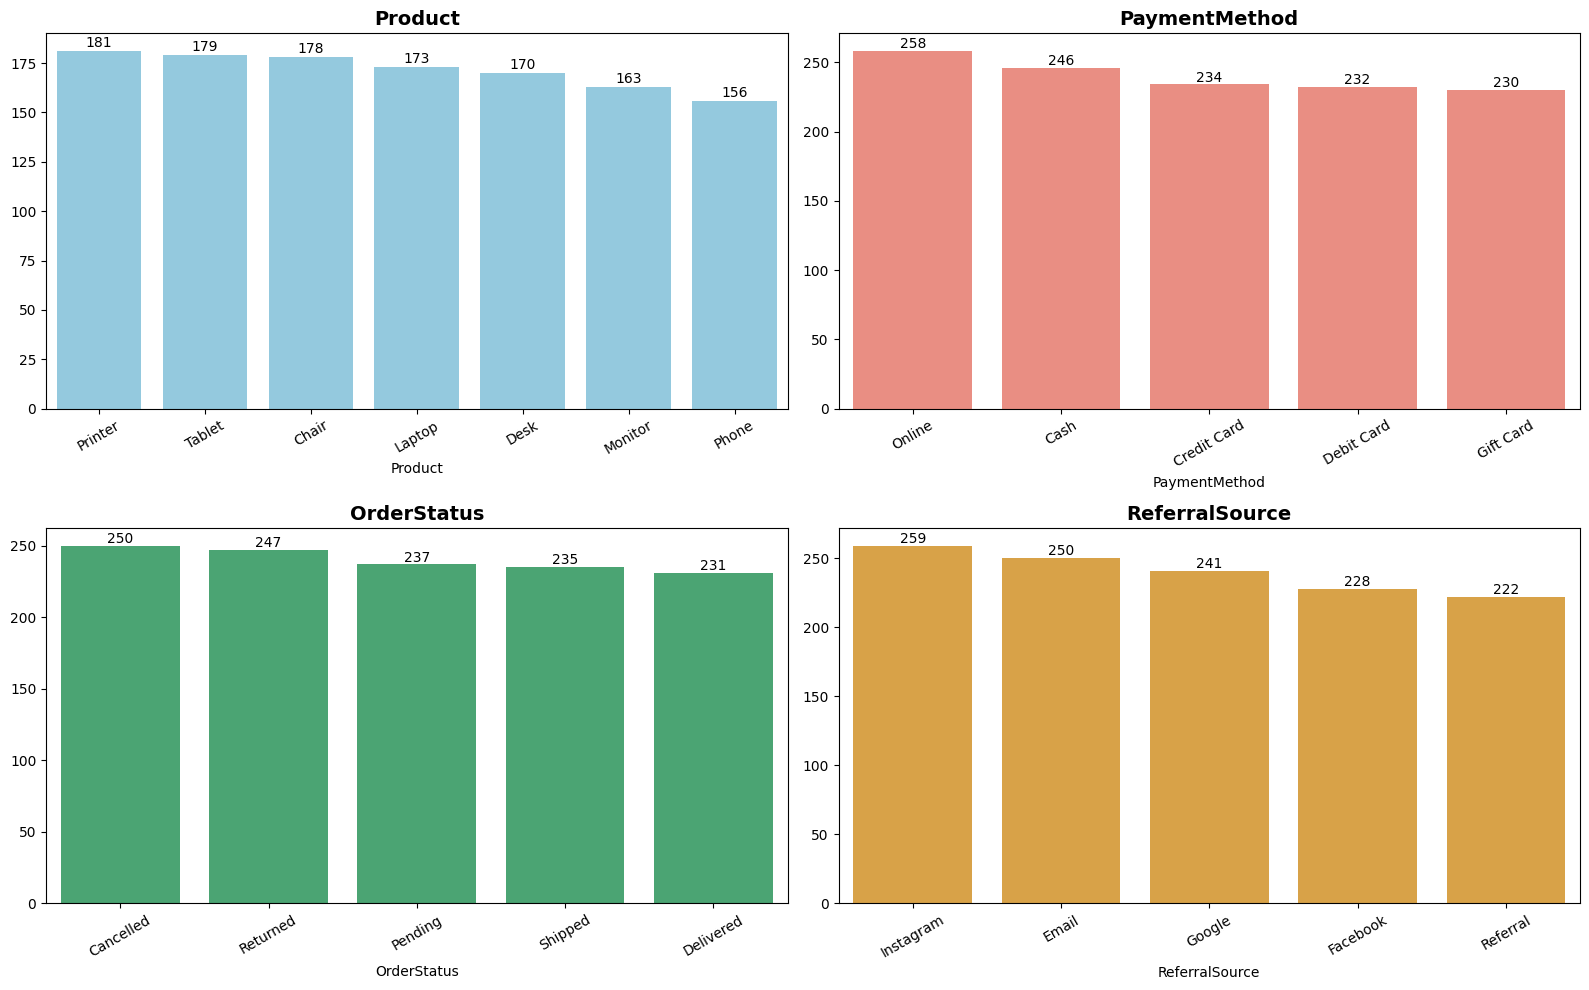

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

categorical_cols = ['Product','PaymentMethod','OrderStatus','ReferralSource']

colors = ['skyblue', 'salmon', 'mediumseagreen', '#F0A830']

for ax, col, color in zip(axes.flatten(),
                          categorical_cols,
                          colors):

    counts = df[col].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=ax,
        color=color
    )

    ax.set_title(col, fontsize=14, weight='bold')
    ax.tick_params(axis='x', rotation=30)

    for i, v in enumerate(counts.values):
        ax.text(i, v+2, str(v), ha='center')

plt.tight_layout()
plt.show()

### 7. Orders & Revenue by Order Status

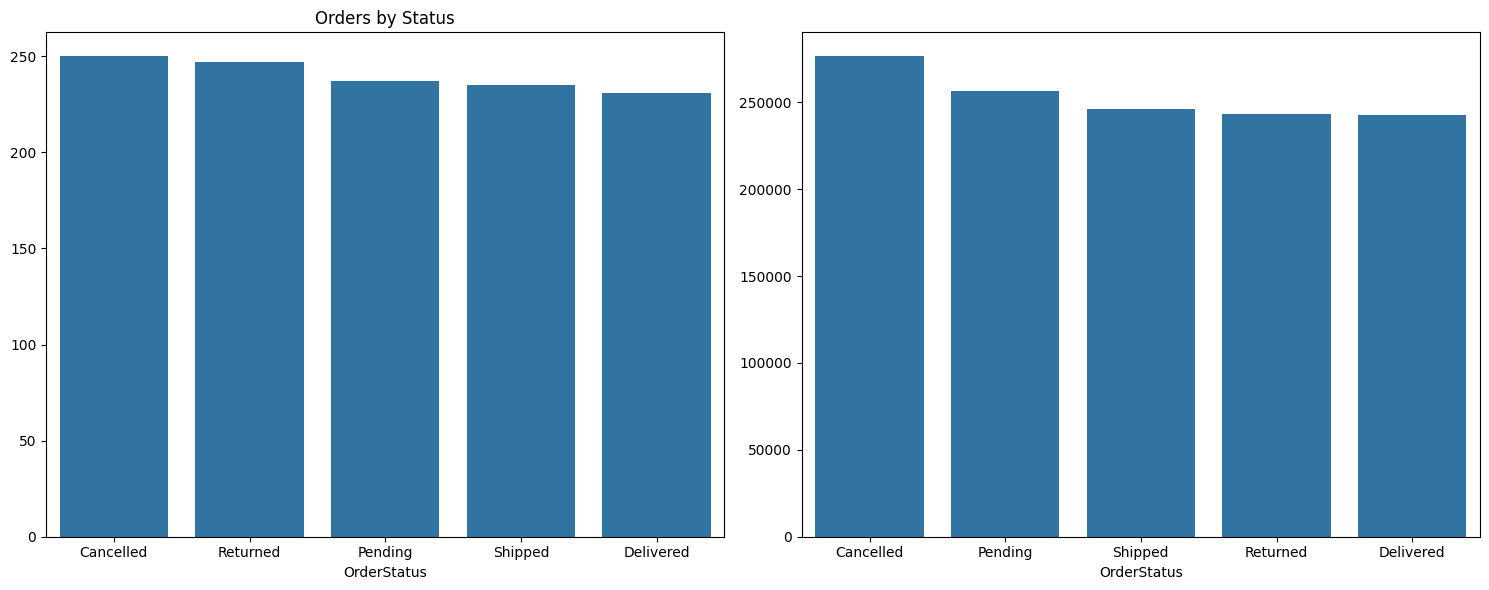

In [23]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

status_count = df['OrderStatus'].value_counts()

sns.barplot(x=status_count.index,y=status_count.values,ax=axes[0])
axes[0].set_title('Orders by Status')

status_revenue = df.groupby('OrderStatus')['TotalPrice'].sum().sort_values(ascending=False)

sns.barplot(x=status_revenue.index,y=status_revenue.values,ax=axes[1])

plt.tight_layout()
plt.show()

### 8. Monthly Revenue Trend

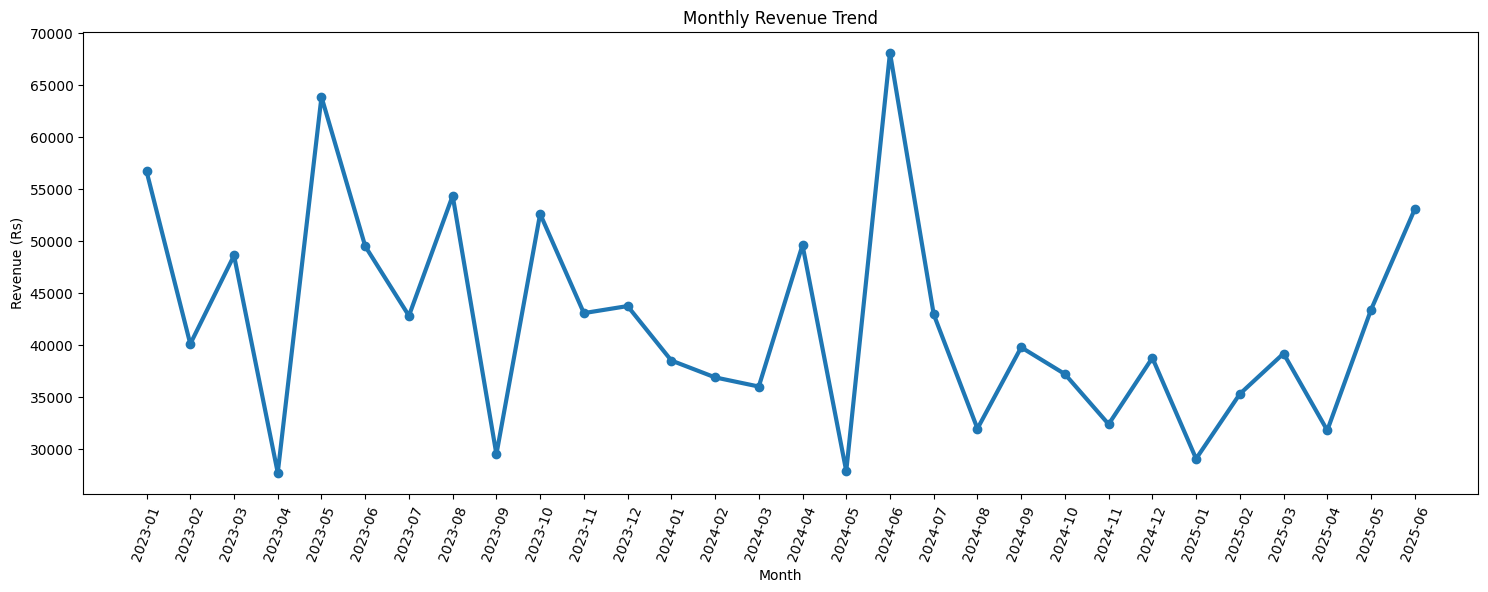

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(18,6))
plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,marker='o',linewidth=3)

plt.xticks(rotation=70)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (Rs)')
plt.xlabel('Month')

plt.show()

### 9.Order & Payment Method Distribution

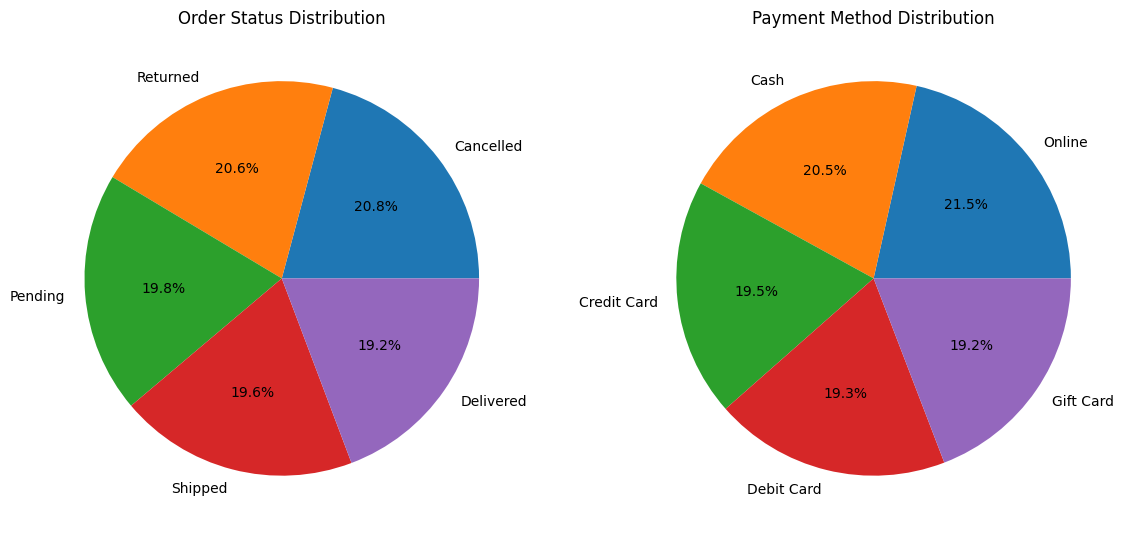

In [25]:
fig, axes = plt.subplots(1,2, figsize=(14,7))

df['OrderStatus'].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=axes[0])

axes[0].set_title('Order Status Distribution')
axes[0].set_ylabel('')

df['PaymentMethod'].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=axes[1])

axes[1].set_title('Payment Method Distribution')
axes[1].set_ylabel('')

plt.show()

### 10.  Revenue by Product per Year

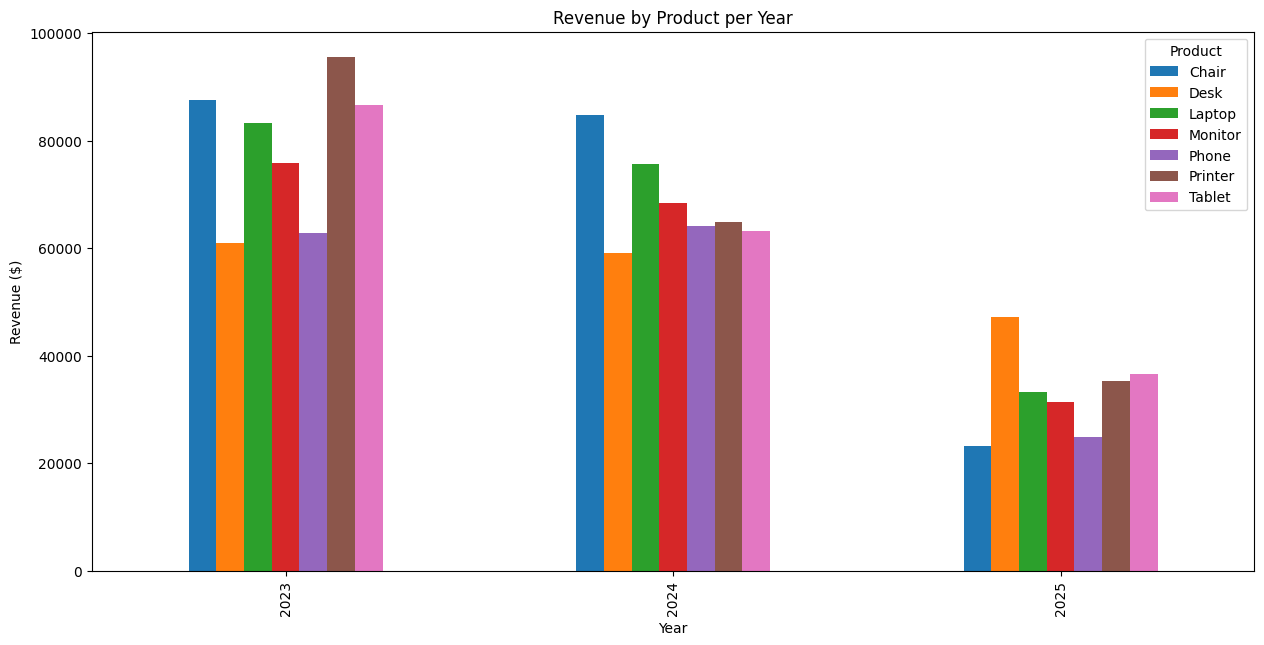

In [26]:
df['Year'] = df['Date'].dt.year

year_product = pd.pivot_table(df,values='TotalPrice',index='Year',
        columns='Product',aggfunc='sum')

year_product.plot(kind='bar',figsize=(15,7))

plt.title('Revenue by Product per Year')
plt.ylabel('Revenue ($)')
plt.show()

### 11. Product Performance

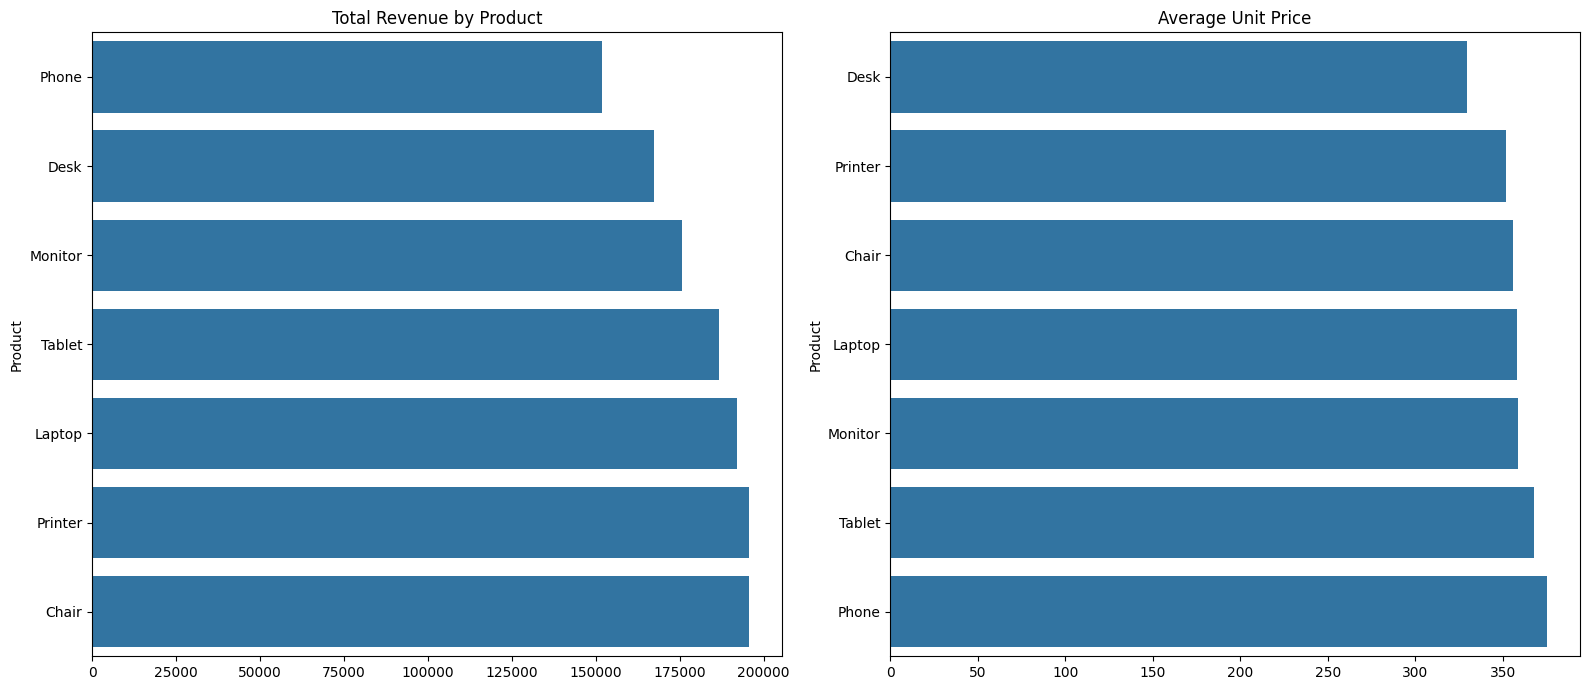

In [27]:
fig, axes = plt.subplots(1,2, figsize=(16,7))

product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values()

sns.barplot(x=product_revenue.values,y=product_revenue.index,ax=axes[0])

axes[0].set_title('Total Revenue by Product')

avg_price = df.groupby('Product')['UnitPrice'].mean().sort_values()


sns.barplot(
    x=avg_price.values,
    y=avg_price.index,
    ax=axes[1]
)

axes[1].set_title('Average Unit Price')

plt.tight_layout()
plt.show()

### 12. Items In Cart Analysis

/tmp/ipykernel_16/1089318628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


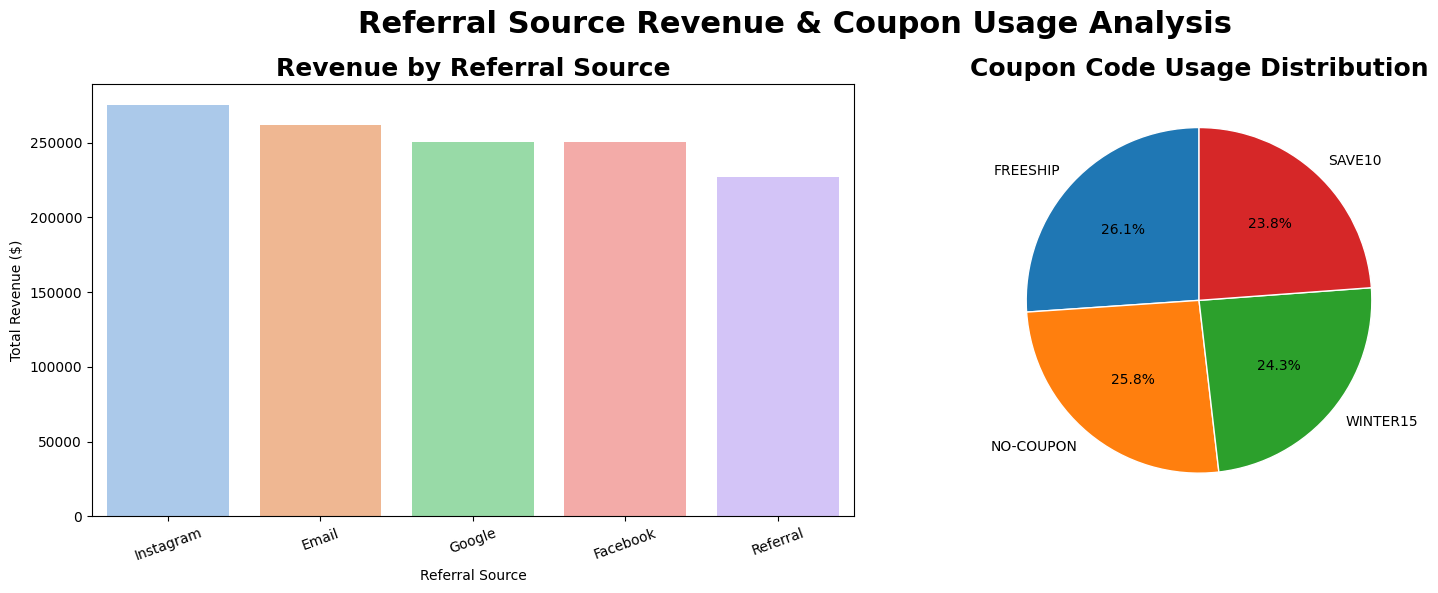

In [28]:
ref_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

coupon_counts = df['CouponCode'].value_counts()

# Create Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x=ref_revenue.index,
    y=ref_revenue.values,
    ax=axes[0],
    palette='pastel'
)

axes[0].set_title(
    'Revenue by Referral Source',
    fontsize=18,
    weight='bold'
)

axes[0].set_xlabel('Referral Source')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(
    coupon_counts.values,
    labels=coupon_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

axes[1].set_title(
    'Coupon Code Usage Distribution',
    fontsize=18,
    weight='bold'
)

plt.suptitle(
    'Referral Source Revenue & Coupon Usage Analysis',
    fontsize=22,
    weight='bold'
)

plt.tight_layout()
plt.show()

### 13. Referral Revenue

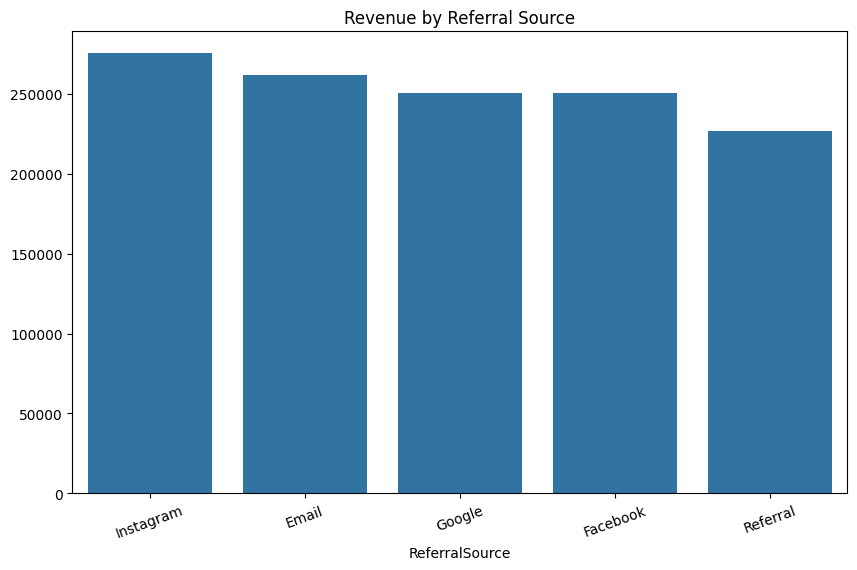

In [29]:
ref_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x=ref_revenue.index,y=ref_revenue.values)

plt.title('Revenue by Referral Source')
plt.xticks(rotation=20)

plt.show()

### 14. Quantity vs Total Price Scatter Plot

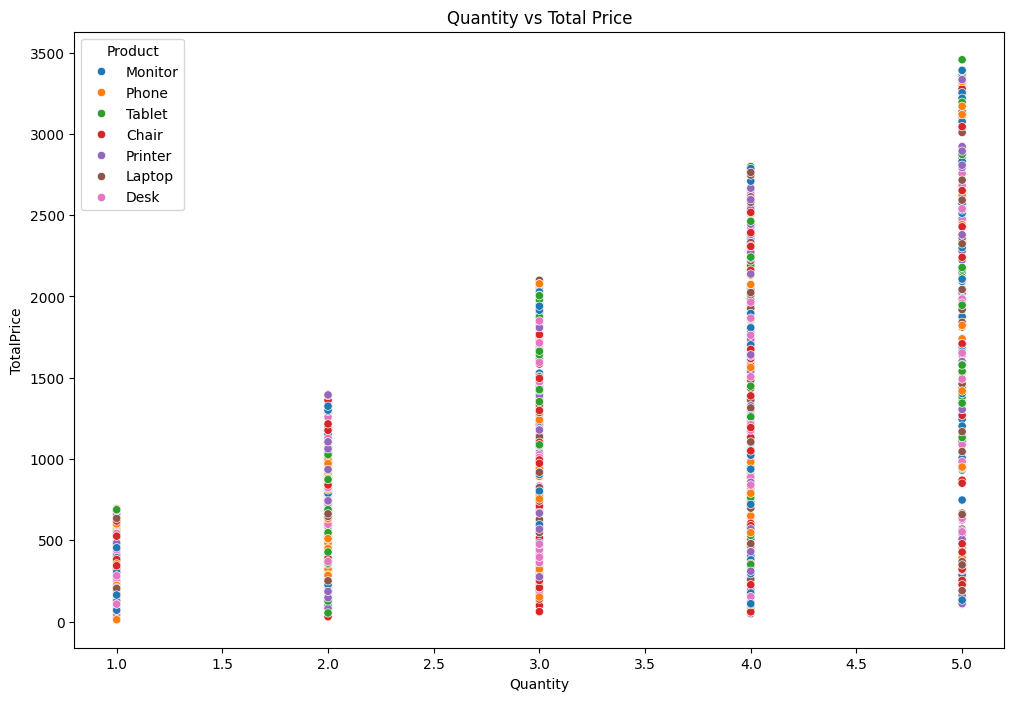

In [30]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice',
    hue='Product'
)

plt.title('Quantity vs Total Price')
plt.show()

### 15. Yearly Sales Performance Dashboard

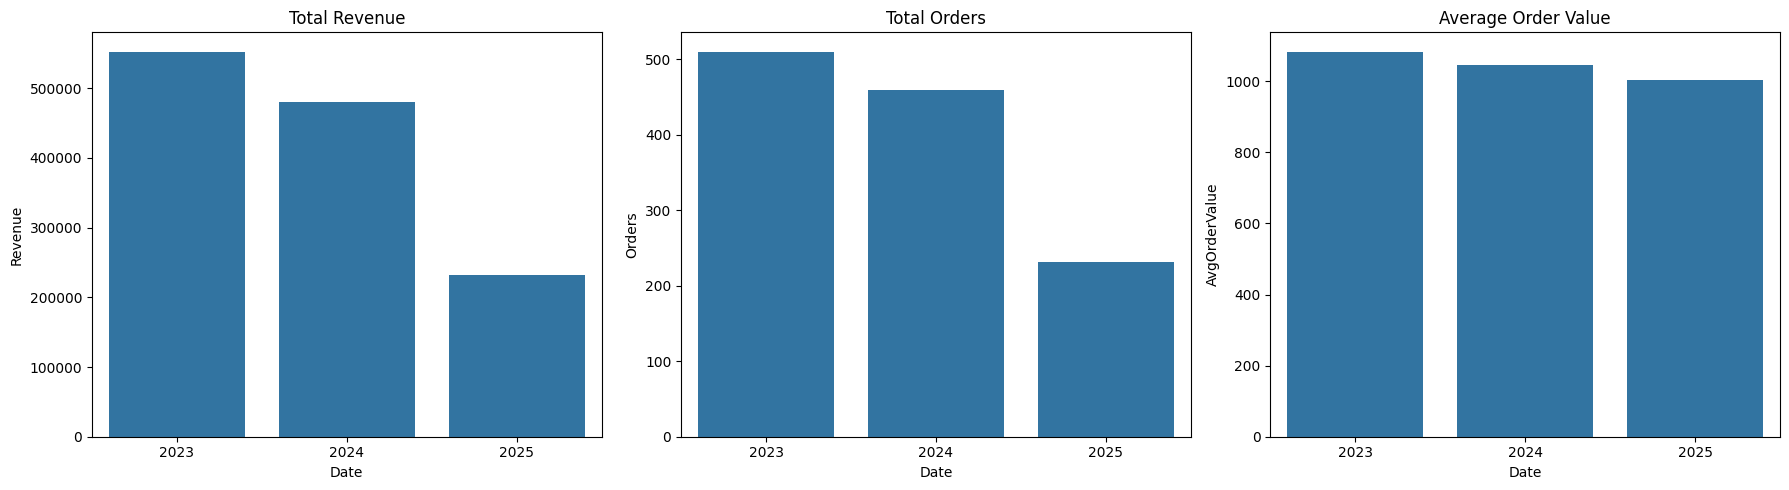

In [31]:
yearly = df.groupby(df['Date'].dt.year).agg(Revenue=('TotalPrice','sum'),
          Orders=('OrderID','count'))

yearly['AvgOrderValue'] = (yearly['Revenue'] / yearly['Orders'])

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.barplot(
    x=yearly.index,
    y=yearly['Revenue'],
    ax=axes[0]
)

axes[0].set_title('Total Revenue')

sns.barplot(
    x=yearly.index,
    y=yearly['Orders'],
    ax=axes[1]
)

axes[1].set_title('Total Orders')

sns.barplot(
    x=yearly.index,
    y=yearly['AvgOrderValue'],
    ax=axes[2]
)

axes[2].set_title('Average Order Value')

plt.tight_layout()
plt.show()